In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [26]:
def read_log_files(directory: str, times: list[float], trajectories: int, number_of_molecules: int):
    T = np.zeros((4,4,len(times)), dtype = np.complex128)

    for i in range(trajectories):
        t, t11, t22, t21r, t31r, t32r, t21i, t31i, t32i = np.loadtxt(f"{directory}/log-{i+1}.txt").T
        T[1,1] += np.interp(times, t, t11)
        T[2,2] += np.interp(times, t, t22)
        T[2,1] += np.interp(times, t, t21r + 1j*t21i)
        T[3,1] += np.interp(times, t, t31r + 1j*t31i)
        T[3,2] += np.interp(times, t, t32r + 1j*t32i)

    T /= trajectories * number_of_molecules
    
    T[1,2] = T[2,1].conj()
    T[3,1] = T[1,3].conj()
    T[2,3] = T[3,2].conj()
    T[1,1] = T[1,1].real
    T[2,2] = T[2,2].real
    T[3,3] = 1 - T[1,1] - T[2,2] # conservation of molecule number
    return T

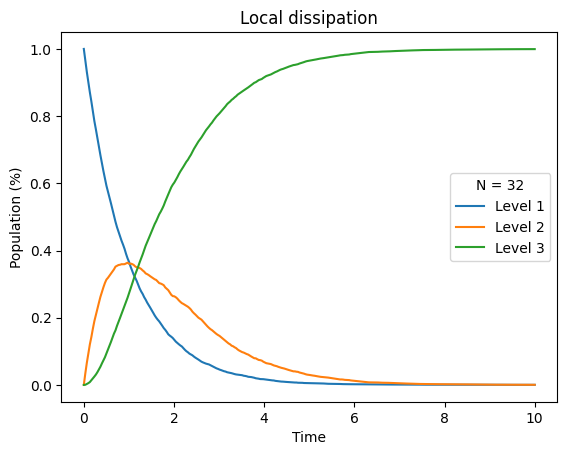

In [27]:
times = np.linspace(0, 10, 300)

T = read_log_files("local", times, trajectories = 200, number_of_molecules = 32)

plt.plot(times, T[1,1], label = "Level 1")
plt.plot(times, T[2,2], label = "Level 2")
plt.plot(times, T[3,3], label = "Level 3")

plt.xlabel("Time")
plt.ylabel("Population (%)")
plt.legend(title = f"N = {number_of_molecules}", loc = "center right")
plt.title("Local dissipation");

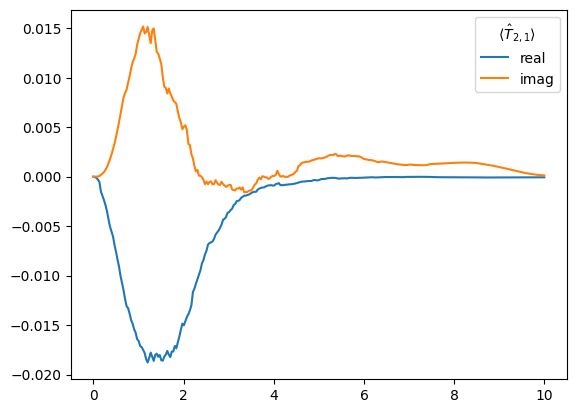

In [28]:
plt.plot(times, T[2,1].real, label = "real")
plt.plot(times, T[2,1].imag, label = "imag")
plt.legend(title = "$\\langle \\hat{T}_{2,1}\\rangle$")

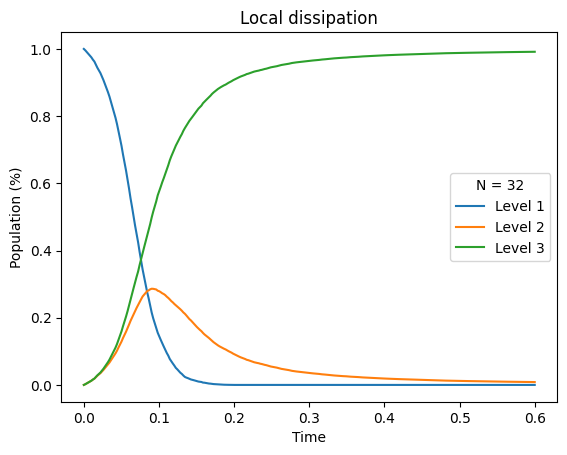

In [33]:
times = np.linspace(0, 0.6, 300)

T = read_log_files("collective", times, trajectories = 200, number_of_molecules = 32)

plt.plot(times, T[1,1], label = "Level 1")
plt.plot(times, T[2,2], label = "Level 2")
plt.plot(times, T[3,3], label = "Level 3")

plt.xlabel("Time")
plt.ylabel("Population (%)")
plt.legend(title = f"N = {number_of_molecules}", loc = "center right")
plt.title("Local dissipation");